In [16]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import SystemMessage, HumanMessage

In [17]:
import sys

print(sys.executable)

c:\Users\amanp\anaconda3\python.exe


In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI

print("Successfully imported!")

Successfully imported!


In [19]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [20]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [21]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [22]:
import os

os.environ["GOOGLE_API_KEY"] = "AQ.Ab8RN6KfT15KB6AROZQL3itB4UBYibpJ44rvSETJCF-C0lA1Vw"

In [23]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

In [24]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [25]:
# def fanout(state: State):
   # # return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
         # for task in state["plan"].tasks]

In [26]:
def worker(payload: dict) -> dict:
    topic = payload["topic"]
    plan = payload["plan"]
    blog_title = plan.blog_title

    sections_brief = "\n\n".join(
        f"### {task.title}\nBrief: {task.brief}" for task in plan.tasks
    )

    response = llm.invoke(
        [
            SystemMessage(
                content="Write a complete blog post in clean Markdown, covering all given sections in order."
            ),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Write these sections:\n\n{sections_brief}\n\n"
                    "Return the full blog content in Markdown, with proper headings for each section."
                )
            ),
        ]
    )

    section_md = response.text.strip()
    return {"sections": [section_md]}

In [27]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [28]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

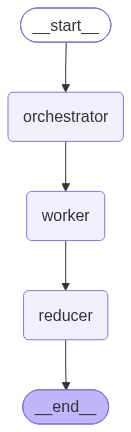

In [29]:
g.add_edge(START, "orchestrator")
g.add_edge("orchestrator", "worker")
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [30]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})